Реализовать с помощью `Numpy` класс `MyMLP`, моделирующий работу полносвязной нейронной сети.

Реализуемый класс должен

1. Поддерживать создание любого числа слоев с любым числом нейронов. Тип инициализации весов не регламентируется.
2. Обеспечивать выбор следующих функции активации в рамках каждого слоя: `ReLU`, `sigmoid`, `linear`.
3. Поддерживать решение задачи классификации и регрессии (выбор соответствующего лосса, в том числе для задачи многоклассовой классификации).
4. В процессе обучения использовать самостоятельно реализованный механизм обратного распространения (вывод формул в формате markdown) для применения градиентного и стохастического градиентного спусков (с выбором размера батча)
5. Поддерживать использование `l1`, `l2` и `l1l2` регуляризаций.

# Библиотеки

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns

!pip install torch

In [ ]:
!pip install torch

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import time
import random
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow import keras

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

#Класс MyMLP

In [ ]:
class MyMLP:
  """ ФУНКЦИИ АКТИВАЦИИ """
  class ReLU:
    def forward(self, X):  # Прямой проход функции активации ReLU
      self.X = X
      return np.maximum(0, X)
    def backward(self, prev_deri): # Обратный проход функции активации ReLU
      return np.multiply(prev_deri, (self.X > 0).astype(float))

  class Sigmoid:
    def forward(self, X): # Прямой проход функции активации sigmoid
      self.X = 1 / (1 + np.exp(-X))
      return self.X
    def backward(self, prev_deri): # Обратный проход функции активации sigmoid
      return prev_deri * self.X * (1- self.X)

  class Linear:
    def forward(self, X): # Прямой проход функции активации linear
      self.X = X
      return X
    def backward(self, prev_deri): # Обратный проход функции активации linear
      return np.multiply(prev_deri, np.ones_like(self.X))

  class Softmax:
    def forward(self, X): # Прямой проход функции активации Softmax
      shift_X = X - np.max(X, axis=1, keepdims=True)
      exp_X = np.exp(shift_X)
      self.X = exp_X / np.sum(exp_X, axis=1, keepdims=True)
      return self.X
    def backward(self, prev_deri): # Обратный проход функции активации Softmax
      return self.X * (prev_deri - np.sum(prev_deri * self.X, axis=1, keepdims=True))

  """ ФУНКЦИИ ПОТЕРЬ """
  class MSE:
    def forward(self, Y_pred, Y_true): # Прямой проход функции потерь MSE
      n = Y_pred.shape[0]
      return (1 / n) * np.sum((Y_true - Y_pred) ** 2)
    def backward(self, Y_pred, Y_true): # Обратный проход функции потерь MSE
      n = Y_pred.shape[0]
      return (2 / n) * (Y_pred - Y_true)

  class CrossEntropy:
    def forward(self,  Y_pred, Y_true): # Прямой проход функции потерь CrossEntropy
      n = Y_pred.shape[0]
      return - (1 / n) * np.sum(Y_true * np.log(Y_pred + 1e-12))
    def backward(self,  Y_pred, Y_true): # Обратный проход функции потерь CrossEntropy
      n = Y_pred.shape[0]
      return - (1 / n) * (Y_true / (Y_pred + 1e-12))

  class Binary_CrossEntropy:
    def forward(self,  Y_pred, Y_true): # Прямой проход функции потерь Binary CrossEntropy
      n = Y_pred.shape[0]
      return - (1 / n) * np.sum(Y_true * np.log(Y_pred + 1e-12) + (1 - Y_true) * np.log(1 - Y_pred + 1e-12))
    def backward(self,  Y_pred, Y_true): # Обратный проход функции потерь Binary CrossEntropy
      n = Y_pred.shape[0]
      return - (1 / n) * (Y_true / (Y_pred + 1e-12) - (1 - Y_true) / (1 - Y_pred + 1e-12))

  """ СЛОЙ """
  class Dense:
    def __init__(self, in_dim, out_dim):

      np.random.seed(42)
      self.W = np.random.normal(size=(in_dim, out_dim)) * np.sqrt(2 / in_dim) # Инициализация весов
      self.b = np.zeros(out_dim) # Инициализация смещения

    def forward(self, X):
      # X - np.array входных данных
      # Возвращает np.array выходов слоя (без функции активации)
      self.X = X
      if X.shape[1] != self.W.shape[0]:
          print('Входные данные имеют неверный размер. Число параметров объекта из X: ',
                X.shape[1], ', входной размер весов W: ', self.W.shape[0])
          return None
      else:
          return np.dot(X, self.W) + self.b

    def backward(self, prev_deri):
      # prev_dery - np.array градиента прошлого шага
      # Возвращает np.array градиента по входам
      return np.dot(prev_deri, self.W.T)

    def grad_W(self, prev_deri):
      # prev_dery - np.array градиента прошлого шага
      # Возвращает np.array градиента по весам
      return np.dot(self.X.T, prev_deri)

    def grad_b(self, prev_deri):
      # prev_dery - np.array градиента прошлого шага
      # Возвращает np.array градиента по смещеню
      return np.sum(prev_deri, axis=0)

  """ ИНИЦИАЛИЗАЦИЯ """
  def __init__(self, Layers, Loss, optimization, batch_size = 16, lambda_1 = 0, lambda_2 = 0,
               alpha = 0.0001, max_iter=5000, early_stopping=0.001, stop_factor = 'grad_norm',
               random_state_seed = 42, verbose = False):
    # Layers - список кортежей, где каждый кортеж состоит из:
    # 1.  объекта MyMLP.Dense с указанием размерностей слоя
    # 2. объекта одной из возможной функции активации (MyMLP.ReLU, MyMLP.Sigmoid, MyMLP.Linear, MyMLP.Softmax)
    # Loss - объект одной из возможной функции потерь (MyMLP.MSE, MyMLP.CrossEntropy, MyMLP.Binary_CrossEntropy)
    # optimization - str, тип поиска решения ('GD' или 'SGD')
    # batch_size - int, размер батча

    #self.Layers = [(MyMLP.Dense(6, 3), MyMLP.Sigmoid())]
    #self.Loss = MyMLP.MSE()

    self.Layers = Layers
    self.Loss = Loss
    self.optimization = optimization
    self.batch_size = batch_size
    self.verbose = verbose
    self.lambda_1 = lambda_1
    self.lambda_2 = lambda_2
    self.alpha = alpha
    self.max_iter = max_iter
    self.early_stopping = early_stopping
    self.stop_factor = stop_factor
    self.random_state_seed = random_state_seed


  """ ПРЯМОЙ ПРОХОД """
  def forward(self, X):
    # X - np.array() данных, поданных на вход нейронной сети
    # возращает значение loss

    data = X
    for dense, act in self.Layers:
      data = dense.forward(data)
      data = act.forward(data)

    return data

  """ ОБРАТНЫЙ ПРОХОД """
  def backward(self, y_pred, y_true):
    # y_pred - np.array(), результат работы нейронной сети
    # y_true - np.array(), реальные значения таргетов
    # Возвращает np.array обновлений весов для каждого слоя
    W_add = []
    b_add = []

    grad = self.Loss.backward(y_pred, y_true) # Градиент функции потерь
    for dense, act in self.Layers[::-1]:
      grad_layer = act.backward(grad) # Градиент функции активации

      grad_add = dense.grad_W(grad_layer) # Градиент сумматора (по весам)
      grad_b = dense.grad_b(grad_layer)

      grad_total = grad_add + self.lambda_1 * np.sign(dense.W) + 2 * self.lambda_2 * dense.W

      grad = dense.backward(grad_layer) # Градиент сумматора (по входам)

      W_add.append(grad_total)
      b_add.append(grad_b)

    return W_add[::-1], b_add[::-1]


  """ ГРАДИЕНТНЫЙ СПУСК """

  def GD(self, X, y_true):
    # X - np.array(), данные, поданные на вход нейронной сети
    # y_true - np.array(), реальные значения таргетов
    # Возвращает list значений функции потерь для каждой итерации

    losses = []
    for i in range(self.max_iter):
        y_pred = self.forward(X)

        loss = self.Loss.forward(y_pred,y_true)
        losses.append(loss)

        grads_W, grads_b = self.backward(y_pred, y_true)

        norm_grad = np.linalg.norm(np.concatenate([g.ravel() for g in grads_W]))
        if norm_grad > 1.0:
          scale = 1.0 / norm_grad
          grads_W = [g * scale for g in grads_W]

        if self.stop_factor == 'grad_norm' and norm_grad < self.early_stopping:
            break
        elif self.stop_factor == 'loss'and i > 2 and abs(loss - losses[-2]) < self.early_stopping:
            break

        for (dense, _), grad_W, grad_b in zip(self.Layers, grads_W, grads_b):
            dense.W =  dense.W - self.alpha * grad_W
            dense.b -= self.alpha * grad_b

        if self.verbose and i % 100 == 0:
          print("Шаг градиентного спуска ", i + 1, ', потери loss: ', loss, ', norm grad: ', norm_grad)
    return losses

  """ СТОХАСТИЧЕСКИЙ ГРАДИЕНТНЫЙ СПУСК """

  def SGD(self, X, y_true):
    # X - np.array(), данные, поданные на вход нейронной сети
    # y_true - np.array(), реальные значения таргетов
    # Возвращает list значений функции потерь для каждой итерации (средняя по батчам)

    losses = []

    for i in range(self.max_iter):
        inds = np.random.permutation(X.shape[0]) # Перемешиваем данные
        X_shuffled = X[inds]
        y_true_shuffled = y_true[inds]

        losses_epoch = []

        for b in range(0, X_shuffled.shape[0], self.batch_size):
          X_batch = X_shuffled[b:b + self.batch_size] # Выделяем подвыборки
          Y_batch = y_true_shuffled[b:b + self.batch_size]

          y_pred = self.forward(X_batch)
          loss = self.Loss.forward(y_pred,Y_batch)
          losses_epoch.append(loss)

          grads_W, grads_b = self.backward(y_pred, Y_batch)
          norm_grad = np.linalg.norm(np.concatenate([g.ravel() for g in grads_W]))
          if norm_grad > 1.0:
            scale = 1.0 / norm_grad
            grads_W = [g * scale for g in grads_W]

          for (dense, _), grad_W, grad_b in zip(self.Layers, grads_W, grads_b):
            dense.W =  dense.W - self.alpha * grad_W
            dense.b -= self.alpha * grad_b

        losses.append(np.mean(losses_epoch))

        norm_grad = np.linalg.norm(np.concatenate([g.ravel() for g in grads_W]))
        if self.stop_factor == 'grad_norm' and norm_grad < self.early_stopping:
          break
        elif self.stop_factor == 'loss' and i > 2 and abs(loss - losses[-2]) < self.early_stopping:
          break

        if self.verbose and i % 100 == 0:
          print("Шаг градиентного спуска ", i + 1, ', потери loss: ', np.mean(losses_epoch), ', norm grad: ', norm_grad)

    return losses

  """ ОБУЧЕНИЕ """
  def fit(self, X, y_true):
    Y = y_true

    if self.optimization == 'GD':
      losses = self.GD(X, Y)
    else:
      losses = self.SGD(X, Y)

    return losses

  """ ПРЕДСКАЗАНИЕ """
  def predict(self, X):
    y_pred = self.forward(X)
    return y_pred

#Тесты

##1. Бинарная классификация

In [ ]:
results_dict = {}

results_dict['MyMLP'] = {}
results_dict['MLPClassifier'] = {}
results_dict['TensorFlow'] = {}
results_dict['Keras'] = {}
results_dict['PyTorch'] = {}

### Обработка данных

In [ ]:
import kagglehub
andrewmvd_heart_failure_clinical_data_path = kagglehub.dataset_download('andrewmvd/heart-failure-clinical-data')
fedesoriano_heart_failure_prediction_path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')

df=pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv")
df = df[:250]

np.random.seed(42)

string_col = df.select_dtypes(include="object").columns
df[string_col]=df[string_col].astype("string")
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

target_col = "HeartDisease"
categorical_cols = X_train.select_dtypes(include=["string"]).columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(feature_names)
print(X_train_processed.shape)

# Преобразуем формат ввода
#X_train = X_train_processed.to_numpy(dtype=np.float32)
y_train = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
#X_test = X_test_processed.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

input_shape = X_train_processed.shape[1]

print(X_train_processed.shape, y_train.shape)

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
['num__Age' 'num__RestingBP' 'num__Cholesterol' 'num__FastingBS'
 'num__MaxHR' 'num__Oldpeak' 'cat__Sex_M' 'cat__ChestPainType_ATA'
 'cat__ChestPainType_NAP' 'cat__ChestPainType_TA' 'cat__RestingECG_Normal'
 'cat__RestingECG_ST' 'cat__ExerciseAngina_Y' 'cat__ST_Slope_Flat'
 'cat__ST_Slope_Up']
(200, 15)
(200, 15) (200, 1)


###**1 вариант.** 1 слой.

**MyMLP**

In [ ]:
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 1), MyMLP.Sigmoid())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.Binary_CrossEntropy(),
              optimization='GD',
              alpha = 0.001, max_iter=5000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['1 conf'] = [f1, fit_time, pred_time]

F1 score:  0.8125
Время обучения:  3.252
Время предсказания:  0.00025


**MLPClassifier**

In [ ]:
start_time = time.time()
model = MLPClassifier(max_iter=5000, random_state = 42, solver='sgd', batch_size=len(X_train_processed))
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPClassifier']['1 conf'] = [f1, fit_time, pred_time]

F1 score:  0.8571428571428571
Время обучения:  1.152
Время предсказания:  0.00082


**TensorFlow**

In [ ]:
start_time = time.time()
X_train_tf = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


W = tf.Variable(tf.random.normal(shape=(input_shape, 1), dtype=tf.float32) * np.sqrt(2 / input_shape))
b = tf.Variable(tf.zeros(shape=(1,), dtype=tf.float32))

learning_rate = 0.001
epochs = 5000
early_stopping = 0.001

def sigmoid(x):
    return tf.nn.sigmoid(x)

def BCE(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred + 1e-12) + (1 - y_true) * tf.math.log(1 - y_pred + 1e-12))

def forward_pass(X):
    linear_output = tf.matmul(X, W) + b
    return sigmoid(linear_output)

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = tf.sigmoid(tf.matmul(X, W) + b)
    loss = BCE(y, y_pred)

  gradients = tape.gradient(loss, [W, b])
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  W.assign_sub(learning_rate * gradients[0])
  b.assign_sub(learning_rate * gradients[1])

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):
  loss, grad_norm = train_step(X_train_tf, y_train_tf)
  history.append(loss.numpy())
  if loss < early_stopping:
    break
end_time = time.time()
fit_time = end_time - start_time

In [ ]:
X_test_tf = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

def predict(X):
  probs = forward_pass(X).numpy()
  return (probs > 0.5).astype(int)

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test_tf, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['1 conf'] = [f1, fit_time, pred_time]

F1 score:  0.7647058823529411
Время обучения:  8.592
Время предсказания:  0.00555


**Keras**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(1, activation=keras.activations.sigmoid))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.BinaryCrossentropy()
)
history = model.fit(X_train_tf, y_train_tf, epochs=5000, batch_size = len(X_train_processed), verbose=0, shuffle = False, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

In [ ]:
start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['1 conf'] = [f1, fit_time, pred_time]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
F1 score:  0.7741935483870968
Время обучения:  226.659
Время предсказания:  0.26657


In [ ]:
X_train_pt = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.float32)
X_test_pt  = torch.tensor(X_test_processed,  dtype=torch.float32)
y_test_pt  = torch.tensor(y_test,  dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 1),
    nn.Sigmoid()
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

start_time = time.time()
model.train()
for epoch in range(5000):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train_pt), y_train_pt)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = (model(X_test_pt) > 0.5).int().numpy()
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['1 conf'] = [f1, fit_time, pred_time]

F1 score:  0.7878787878787878
Время обучения:  3.116
Время предсказания:  0.00038


In [ ]:
results_dict['PyTorch']['1 conf'] = [f1, fit_time, pred_time]

**Визуализация**

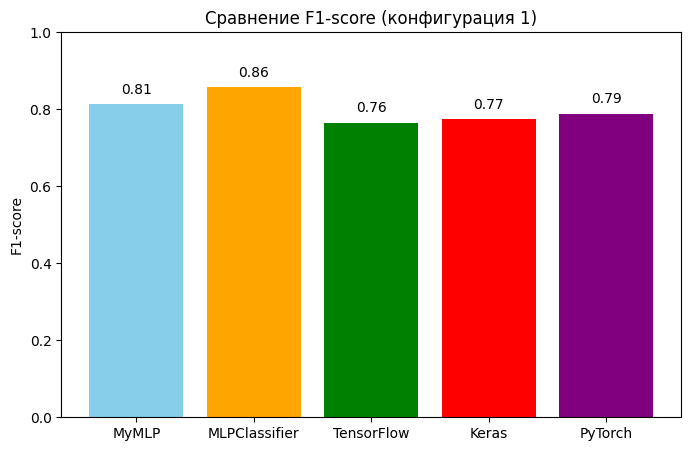

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['1 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 1)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

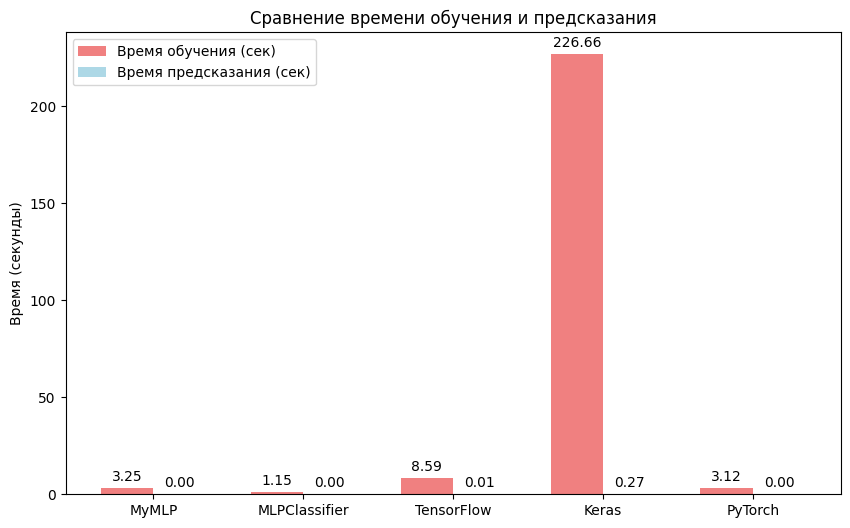

In [ ]:
fit_times = [results_dict[f]['1 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['1 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**2 вариант.** 2 скрытых слоя (16, 32) .

**MyMLP**

In [ ]:
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 32), MyMLP.ReLU()),
     (MyMLP.Dense(32, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 1), MyMLP.Sigmoid())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.Binary_CrossEntropy(),
              optimization='SGD', batch_size = 32,
              alpha = 0.001, max_iter=1500)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['2 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9444444444444444
Время обучения:  1.954
Время предсказания:  0.00019


**MLPClassifier**

In [ ]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1500, random_state = 42, solver='sgd', batch_size=32)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPClassifier']['2 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  3.539
Время предсказания:  0.00071


**TensorFlow**

In [ ]:
start_time = time.time()

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
hidden1_dim = 32
hidden2_dim = 16
output_dim = 1

def he_init(shape):
    return tf.Variable(tf.random.normal(shape) * np.sqrt(2.0 / shape[0]))

W1 = he_init((input_dim, hidden1_dim))
b1 = tf.Variable(tf.zeros((hidden1_dim,), dtype=tf.float32))

W2 = he_init((hidden1_dim, hidden2_dim))
b2 = tf.Variable(tf.zeros((hidden2_dim,), dtype=tf.float32))

W3 = he_init((hidden2_dim, output_dim))
b3 = tf.Variable(tf.zeros((output_dim,), dtype=tf.float32))


learning_rate = 0.001
epochs = 1500
early_stopping = 0.001
batch_size = 32

def sigmoid(x):
    return tf.nn.sigmoid(x)

def relu(x):
  return tf.nn.relu(x)

def linear(x):
  return x

def BCE(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred + 1e-12) + (1 - y_true) * tf.math.log(1 - y_pred + 1e-12))

def forward_pass(X):
    # Слой 1
    z1 = tf.matmul(X, W1) + b1
    a1 = relu(z1)
    # Слой 2
    z2 = tf.matmul(a1, W2) + b2
    a2 = relu(z2)
    # Слой 3
    z3 = tf.matmul(a2, W3) + b3
    a3 = sigmoid(z3)
    return a3

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    loss = BCE(y, y_pred)

  gradients = tape.gradient(loss, [W1, b1, W2, b2, W3, b3])
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip([W1, b1, W2, b2, W3, b3], gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []

  for i in range(0, X_train_tf.shape[0], batch_size):
    x_batch = X_train_tf[i:i+batch_size]
    y_batch = y_train_tf[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break


end_time = time.time()
fit_time = end_time - start_time

def predict(X):
  probs = forward_pass(X).numpy()
  return (probs > 0.5).astype(int)

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test_tf, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['2 conf'] = [f1, fit_time, pred_time]

F1 score:  0.8823529411764706
Время обучения:  25.052
Время предсказания:  0.01145


**Keras**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(32, activation=keras.activations.relu))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(1, activation=keras.activations.sigmoid))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.BinaryCrossentropy()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1500, batch_size = 32, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['2 conf'] = [f1, fit_time, pred_time]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
F1 score:  0.918918918918919
Время обучения:  95.261
Время предсказания:  0.34654


**PyTorch**

In [ ]:
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

start_time = time.time()
model.train()
for epoch in range(5000):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = (model(X_test_pt) > 0.5).int().numpy()
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['2 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  48.225
Время предсказания:  0.00047


**Визуализация**

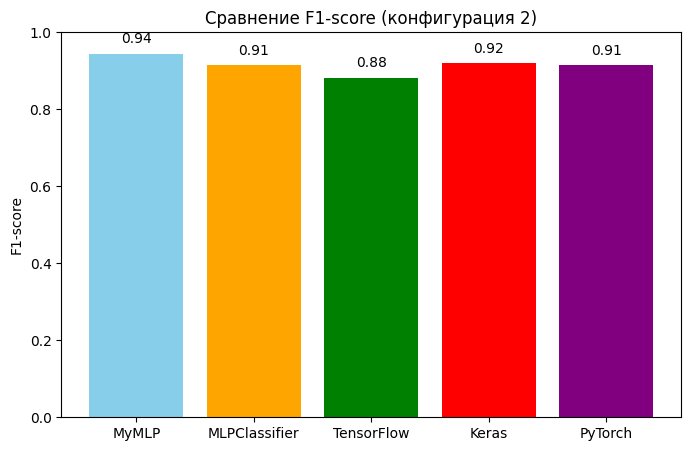

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['2 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 2)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

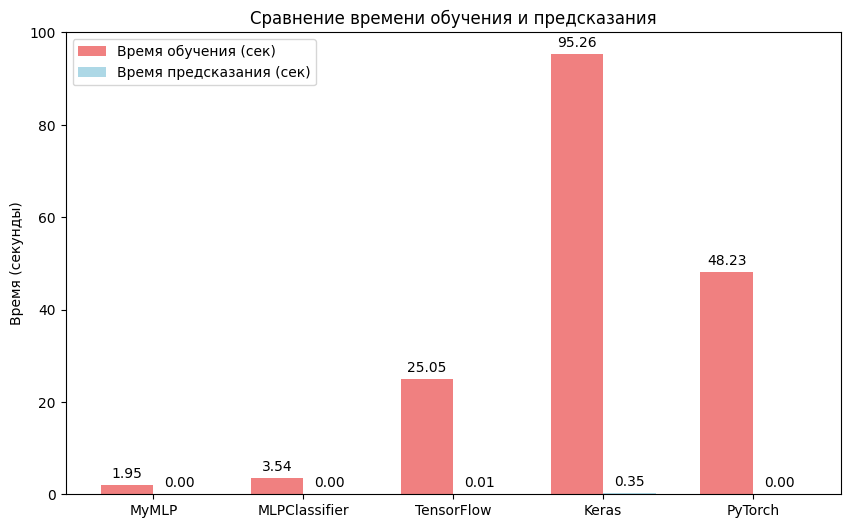

In [ ]:
fit_times = [results_dict[f]['2 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['2 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**3 вариант.** 3 скрытых слоя (16, 16, 16) .

**MyMLP**

In [ ]:
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 1), MyMLP.Sigmoid()),
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.Binary_CrossEntropy(),
              optimization='SGD', batch_size = 16,
              alpha = 0.001, max_iter=1500)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['3 conf'] = [f1, fit_time, pred_time]

F1 score:  0.8823529411764706
Время обучения:  4.064
Время предсказания:  0.00021


**MLPClassifier**

In [ ]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes=(16, 16, 16), max_iter=1500, random_state = 42, solver='sgd', batch_size=16)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPClassifier']['3 conf'] = [f1, fit_time, pred_time]

F1 score:  0.972972972972973
Время обучения:  5.462
Время предсказания:  0.00061


**TensorFlow**

In [ ]:
start_time = time.time()

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
output_dims = [16, 16, 16, 1]

def he_init(shape):
    return tf.Variable(tf.random.normal(shape, dtype=tf.float32) * np.sqrt(2.0 / shape[0]))

W = [he_init((input_dim, output_dims[0]))]
b = [tf.Variable(tf.zeros((output_dims[0],), dtype=tf.float32))]
WB = []

for i in range(1, len(output_dims)):
  W.append(he_init((output_dims[i-1], output_dims[i])))
  b.append(tf.Variable(tf.zeros((output_dims[i],), dtype=tf.float32)))

for i in range(0, len(output_dims)):
  WB.append(W[i])
  WB.append(b[i])

learning_rate = 0.001
epochs = 1500
early_stopping = 0.0001
batch_size = 16

def sigmoid(x):
    return tf.nn.sigmoid(x)

def relu(x):
  return tf.nn.relu(x)

def BCE(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred + 1e-12) + (1 - y_true) * tf.math.log(1 - y_pred + 1e-12))

def forward_pass(X):
  z = tf.matmul(X, W[0]) + b[0]
  a = relu(z)
  for i in range (1, len(output_dims) - 1):
    z = tf.matmul(a, W[i]) + b[i]
    z = tf.clip_by_value(z, -10.0, 10.0)
    a = relu(z)
  z = tf.matmul(a, W[len(output_dims) - 1]) + b[len(output_dims) - 1]
  a = sigmoid(z)
  return a

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    loss = BCE(y, y_pred)

  gradients = tape.gradient(loss, WB)
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip(WB, gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []
  indices = tf.random.shuffle(tf.range(X_train_tf.shape[0]))
  X_shuffled = tf.gather(X_train_tf, indices)
  y_true_shuffled = tf.gather(y_train_tf, indices)

  for i in range(0, X_shuffled.shape[0], batch_size):
    x_batch = X_shuffled[i:i+batch_size]
    y_batch = y_true_shuffled[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break


end_time = time.time()
fit_time = end_time - start_time


f1 = f1_score(y_test_tf, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['3 conf'] = [f1, fit_time, pred_time]

F1 score:  0.972972972972973
Время обучения:  53.133
Время предсказания:  0.00061


**Keras**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(1, activation=keras.activations.sigmoid))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.BinaryCrossentropy()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1500, batch_size = 16, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['3 conf'] = [f1, fit_time, pred_time]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
F1 score:  0.9142857142857143
Время обучения:  132.613
Время предсказания:  0.42332


**PyTorch**

In [ ]:
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=16)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

start_time = time.time()
model.train()
for epoch in range(1500):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = (model(X_test_pt) > 0.5).int().numpy()
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['3 conf'] = [f1, fit_time, pred_time]

F1 score:  0.8571428571428571
Время обучения:  26.737
Время предсказания:  0.0005


**Визуализация**

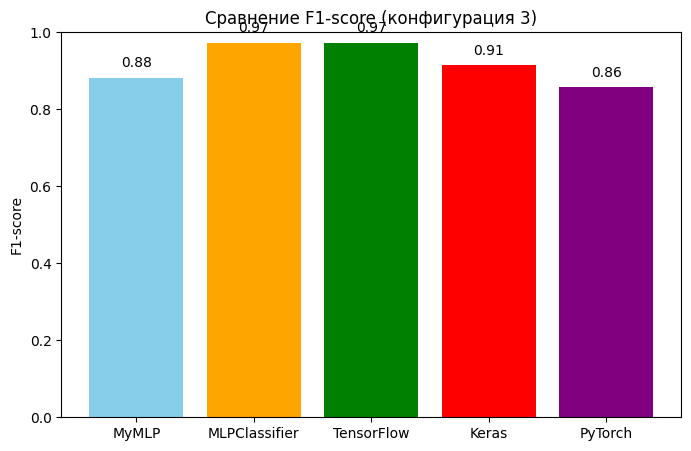

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['3 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 3)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

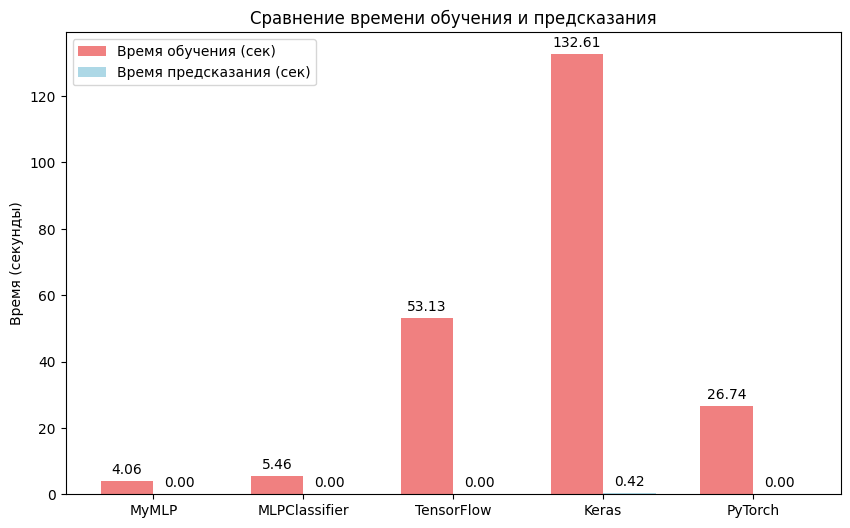

In [ ]:
fit_times = [results_dict[f]['3 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['3 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**4 вариант.** 4 скрытых слоя (128, 256, 64, 32) .

**MyMLP**

In [ ]:
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 128), MyMLP.ReLU()),
     (MyMLP.Dense(128, 256), MyMLP.ReLU()),
     (MyMLP.Dense(256, 64), MyMLP.ReLU()),
    (MyMLP.Dense(64, 32), MyMLP.ReLU()),
     (MyMLP.Dense(32, 1), MyMLP.Sigmoid()),
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.Binary_CrossEntropy(),
              optimization='SGD', batch_size = 32,
              alpha = 0.001, max_iter=1500)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['4 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  20.696
Время предсказания:  0.00193


**MLPClassifier**

In [ ]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes=(128, 256, 64, 32), max_iter=1500, random_state = 42, solver='sgd', batch_size=32)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPClassifier']['4 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  11.923
Время предсказания:  0.00112


**TensorFlow**

In [ ]:
start_time = time.time()

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
output_dims = [128, 256, 64, 32, 1]

def he_init(shape):
    return tf.Variable(tf.random.normal(shape, dtype=tf.float32) * np.sqrt(2.0 / shape[0]))

W = [he_init((input_dim, output_dims[0]))]
b = [tf.Variable(tf.zeros((output_dims[0],), dtype=tf.float32))]
WB = []

for i in range(1, len(output_dims)):
  W.append(he_init((output_dims[i-1], output_dims[i])))
  b.append(tf.Variable(tf.zeros((output_dims[i],), dtype=tf.float32)))

for i in range(0, len(output_dims)):
  WB.append(W[i])
  WB.append(b[i])

learning_rate = 0.001
epochs = 1500
early_stopping = 0.0001
batch_size = 32

def sigmoid(x):
    return tf.nn.sigmoid(x)

def relu(x):
  return tf.nn.relu(x)

def BCE(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred + 1e-12) + (1 - y_true) * tf.math.log(1 - y_pred + 1e-12))

def forward_pass(X):
  z = tf.matmul(X, W[0]) + b[0]
  a = relu(z)
  for i in range (1, len(output_dims) - 1):
    z = tf.matmul(a, W[i]) + b[i]
    z = tf.clip_by_value(z, -10.0, 10.0)
    a = relu(z)
  z = tf.matmul(a, W[len(output_dims) - 1]) + b[len(output_dims) - 1]
  a = sigmoid(z)
  return a

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    loss = BCE(y, y_pred)

  gradients = tape.gradient(loss, WB)
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip(WB, gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []
  indices = tf.random.shuffle(tf.range(X_train_tf.shape[0]))
  X_shuffled = tf.gather(X_train_tf, indices)
  y_true_shuffled = tf.gather(y_train_tf, indices)

  for i in range(0, X_shuffled.shape[0], batch_size):
    x_batch = X_shuffled[i:i+batch_size]
    y_batch = y_true_shuffled[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break


end_time = time.time()
fit_time = end_time - start_time


f1 = f1_score(y_test_tf, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['4 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  32.765
Время предсказания:  0.00112


**Keras**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(128, activation=keras.activations.relu))
model.add(keras.layers.Dense(256, activation=keras.activations.relu))
model.add(keras.layers.Dense(64, activation=keras.activations.relu))
model.add(keras.layers.Dense(32, activation=keras.activations.relu))
model.add(keras.layers.Dense(1, activation=keras.activations.sigmoid))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.BinaryCrossentropy()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1500, batch_size = 32, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['4 conf'] = [f1, fit_time, pred_time]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
F1 score:  0.972972972972973
Время обучения:  102.198
Время предсказания:  0.44088


**PyTorch**

In [ ]:
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

start_time = time.time()
model.train()
for epoch in range(1500):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = (model(X_test_pt) > 0.5).int().numpy()
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['4 conf'] = [f1, fit_time, pred_time]

F1 score:  0.8125
Время обучения:  20.774
Время предсказания:  0.00087


**Визуализация**

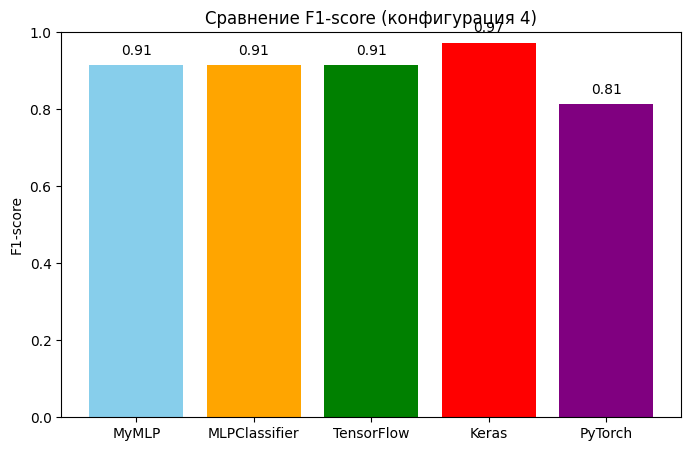

In [ ]:
frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['4 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 4)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

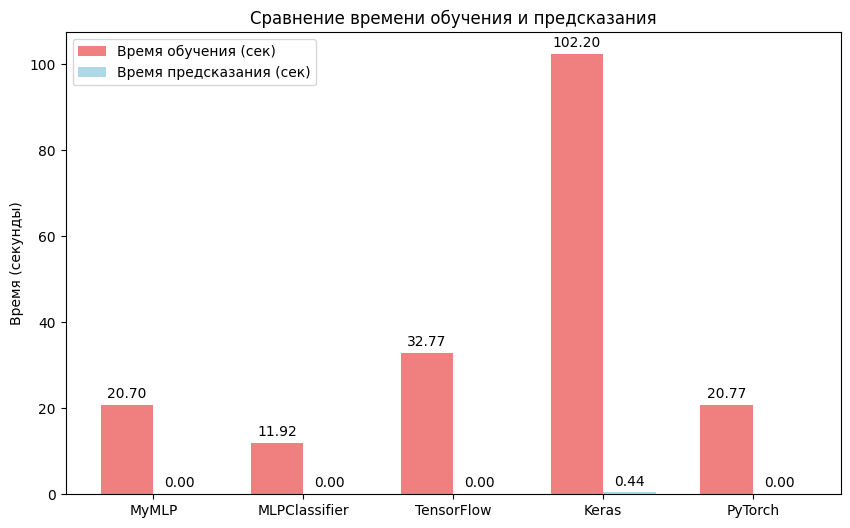

In [ ]:
fit_times = [results_dict[f]['4 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['4 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**5 вариант.** 3 скрытых слоя (512, 256, 128) + регуляризация.

**MyMLP**

In [ ]:
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 512), MyMLP.ReLU()),
     (MyMLP.Dense(512, 256), MyMLP.ReLU()),
    (MyMLP.Dense(256, 128), MyMLP.ReLU()),
     (MyMLP.Dense(128, 1), MyMLP.Sigmoid()),
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.Binary_CrossEntropy(),
              optimization='SGD', batch_size = 32, lambda_2 = 0.001,
              alpha = 0.001, max_iter=5000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['5 conf'] = [f1, fit_time, pred_time]

F1 score:  0.918918918918919
Время обучения:  165.58
Время предсказания:  0.00126


**MLPClassifier**

In [ ]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes=(512, 256, 128), max_iter=1500, random_state = 42, solver='sgd', batch_size=32, alpha=0.001)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPClassifier']['5 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  25.59
Время предсказания:  0.00159


**TensorFlow**

In [ ]:
start_time = time.time()

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
output_dims = [512, 256, 128]

def he_init(shape):
    return tf.Variable(tf.random.normal(shape, dtype=tf.float32) * np.sqrt(2.0 / shape[0]))

W = [he_init((input_dim, output_dims[0]))]
b = [tf.Variable(tf.zeros((output_dims[0],), dtype=tf.float32))]
WB = []

for i in range(1, len(output_dims)):
  W.append(he_init((output_dims[i-1], output_dims[i])))
  b.append(tf.Variable(tf.zeros((output_dims[i],), dtype=tf.float32)))

for i in range(0, len(output_dims)):
  WB.append(W[i])
  WB.append(b[i])

learning_rate = 0.001
epochs = 1500
early_stopping = 0.0001
batch_size = 32
l2_lambda = 0.001

def sigmoid(x):
    return tf.nn.sigmoid(x)

def relu(x):
  return tf.nn.relu(x)

def BCE(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred + 1e-12) + (1 - y_true) * tf.math.log(1 - y_pred + 1e-12))

def forward_pass(X):
  z = tf.matmul(X, W[0]) + b[0]
  a = relu(z)
  for i in range (1, len(output_dims) - 1):
    z = tf.matmul(a, W[i]) + b[i]
    z = tf.clip_by_value(z, -10.0, 10.0)
    a = relu(z)
  z = tf.matmul(a, W[len(output_dims) - 1]) + b[len(output_dims) - 1]
  a = sigmoid(z)
  return a

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    bce_loss = BCE(y, y_pred)
    l2_loss = l2_lambda * tf.add_n([tf.reduce_sum(tf.square(w)) for w in W])
    loss = bce_loss + l2_loss


  gradients = tape.gradient(loss, WB)
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip(WB, gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []
  indices = tf.random.shuffle(tf.range(X_train_tf.shape[0]))
  X_shuffled = tf.gather(X_train_tf, indices)
  y_true_shuffled = tf.gather(y_train_tf, indices)

  for i in range(0, X_shuffled.shape[0], batch_size):
    x_batch = X_shuffled[i:i+batch_size]
    y_batch = y_true_shuffled[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break


end_time = time.time()
fit_time = end_time - start_time


f1 = f1_score(y_test_tf, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['5 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  29.578
Время предсказания:  0.00159


**Keras**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(512, kernel_regularizer=keras.regularizers.l2(0.001), activation=keras.activations.relu))
model.add(keras.layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.001), activation=keras.activations.relu))
model.add(keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(0.001), activation=keras.activations.relu))
model.add(keras.layers.Dense(1, kernel_regularizer=keras.regularizers.l2(0.001), activation=keras.activations.sigmoid))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.BinaryCrossentropy()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1500, batch_size = 32, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = (model.predict(X_test_processed) > 0.5).astype(int)
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['5 conf'] = [f1, fit_time, pred_time]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
F1 score:  1.0
Время обучения:  96.212
Время предсказания:  0.39701


**PyTorch**

In [ ]:
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, weight_decay = 0.001)
loss_fn = nn.BCELoss()

start_time = time.time()
model.train()
for epoch in range(1500):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = (model(X_test_pt) > 0.5).int().numpy()
end_time = time.time()
pred_time = end_time - start_time

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['5 conf'] = [f1, fit_time, pred_time]

F1 score:  0.9142857142857143
Время обучения:  24.526
Время предсказания:  0.00124


**Визуализация**

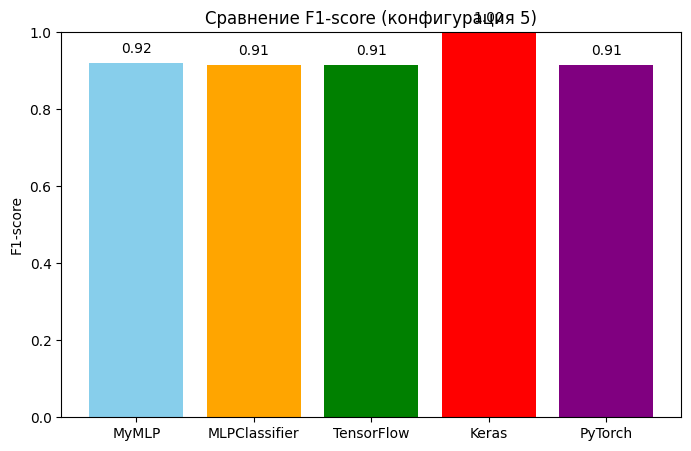

In [ ]:
frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['5 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 5)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

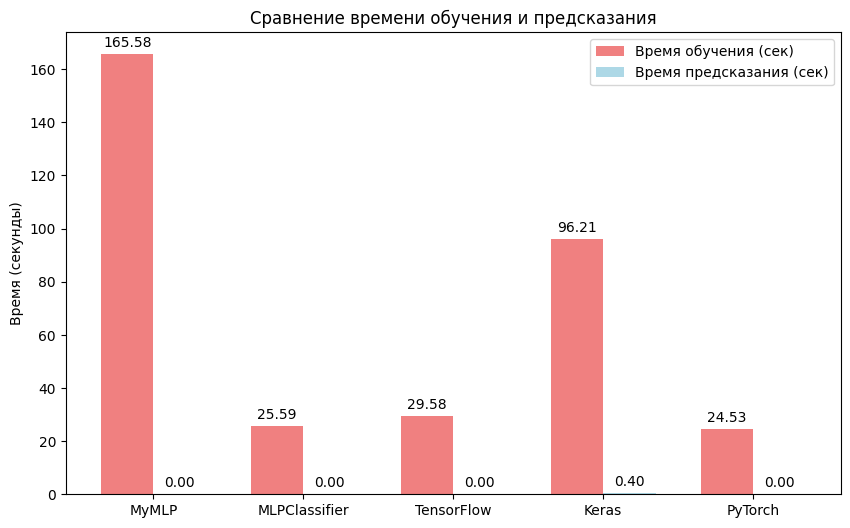

In [ ]:
fit_times = [results_dict[f]['5 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['5 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

In [ ]:
classification_res = results_dict

In [ ]:
pd.DataFrame(classification_res)

,MyMLP,MLPClassifier,TensorFlow,Keras,PyTorch
1 conf,"[0.8125, 3.2519402503967285, 0.000252723693847...","[0.8571428571428571, 1.1519408226013184, 0.000...","[0.7647058823529411, 8.591562747955322, 0.0055...","[0.7741935483870968, 226.65866899490356, 0.266...","[0.7878787878787878, 3.115805149078369, 0.0003..."
2 conf,"[0.9444444444444444, 1.954406499862671, 0.0001...","[0.9142857142857143, 3.538567543029785, 0.0007...","[0.8823529411764706, 25.05175471305847, 0.0114...","[0.918918918918919, 95.26080274581909, 0.34654...","[0.9142857142857143, 48.22513127326965, 0.0004..."
3 conf,"[0.8823529411764706, 4.06374192237854, 0.00020...","[0.972972972972973, 5.461947441101074, 0.00061...","[0.972972972972973, 53.13291358947754, 0.00061...","[0.9142857142857143, 132.6127917766571, 0.4233...","[0.8571428571428571, 26.737237691879272, 0.000..."
4 conf,"[0.9142857142857143, 20.69613790512085, 0.0019...","[0.9142857142857143, 11.923366069793701, 0.001...","[0.9142857142857143, 32.76538872718811, 0.0011...","[0.972972972972973, 102.19829177856445, 0.4408...","[0.8125, 20.773708820343018, 0.000865936279296..."
5 conf,"[0.918918918918919, 165.58045268058777, 0.0012...","[0.9142857142857143, 25.58958673477173, 0.0015...","[0.9142857142857143, 29.578043460845947, 0.001...","[1.0, 96.21199679374695, 0.3970057964324951]","[0.9142857142857143, 24.525545358657837, 0.001..."


In [ ]:
pd.DataFrame(classification_res).to_csv('classification_res.csv', index=False)

## 2. Регрессия (датасет: California Housing)

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X, y = housing.data, housing.target
y = y.reshape(-1, 1)

X = X[:800]
y = y[:800]

# Разделяем
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабируем признаки
scaler = StandardScaler()
X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)

input_shape = X_train_processed.shape[1]

print(f"Размер обучающей выборки: {X_train_processed.shape}")
print(f"Размер тестовой выборки: {X_test_processed.shape}")

Размер обучающей выборки: (640, 8)
Размер тестовой выборки: (160, 8)


In [ ]:
results_dict = {}

results_dict['MyMLP'] = {}
results_dict['TensorFlow'] = {}
results_dict['Keras'] = {}
results_dict['PyTorch'] = {}

In [ ]:
results_dict['MLPRegressor'] = {}

###**1 вариант.** 1 слой.

In [ ]:
#MyMLP

start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 1), MyMLP.Linear())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.MSE(),
              optimization='GD',
              alpha = 0.001, max_iter=5000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)

print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['1 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7287254204354323
Время обучения:  0.62
Время предсказания:  0.00018


In [ ]:
#MLPRegressor
start_time = time.time()
model = MLPRegressor(max_iter=5000, random_state = 42, solver='sgd', batch_size=len(X_train_processed))
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)

print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPRegressor']['1 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7960174104659015
Время обучения:  0.684
Время предсказания:  0.00078


In [ ]:
# TensorFlow
start_time = time.time()
X_train_tf = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


W = tf.Variable(tf.random.normal(shape=(input_shape, 1), dtype=tf.float32) * np.sqrt(2 / input_shape))
b = tf.Variable(tf.zeros(shape=(1,), dtype=tf.float32))

learning_rate = 0.001
epochs = 5000
early_stopping = 0.001


def MSE(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def forward_pass(X):
    linear_output = tf.matmul(X, W) + b
    return linear_output

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = tf.matmul(X, W) + b
    loss = MSE(y, y_pred)

  gradients = tape.gradient(loss, [W, b])
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  W.assign_sub(learning_rate * gradients[0])
  b.assign_sub(learning_rate * gradients[1])

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):
  loss, grad_norm = train_step(X_train_tf, y_train_tf)
  history.append(loss.numpy())
  if loss < early_stopping:
    break
end_time = time.time()
fit_time = end_time - start_time

X_test_tf = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

def predict(X):
  probs = forward_pass(X).numpy()
  return probs

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['1 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7473642129536842
Время обучения:  15.536
Время предсказания:  0.00456


In [ ]:
# Keras
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(1, activation=keras.activations.linear))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.MeanSquaredError()
)
history = model.fit(X_train_tf, y_train_tf, epochs=5000, batch_size = len(X_train_processed), verbose=0, shuffle = False, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['1 conf'] = [r2, fit_time, pred_time]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
R2 score:  0.7252512452682518
Время обучения:  91.219
Время предсказания:  0.1505


In [ ]:
# PyTorch
X_train_pt = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.float32)
X_test_pt  = torch.tensor(X_test_processed,  dtype=torch.float32)
y_test_pt  = torch.tensor(y_test,  dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

start_time = time.time()
model.train()
for epoch in range(5000):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train_pt), y_train_pt)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = model(X_test_pt).numpy()
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['1 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7474166966295659
Время обучения:  2.884
Время предсказания:  0.00026


**Визуализация**

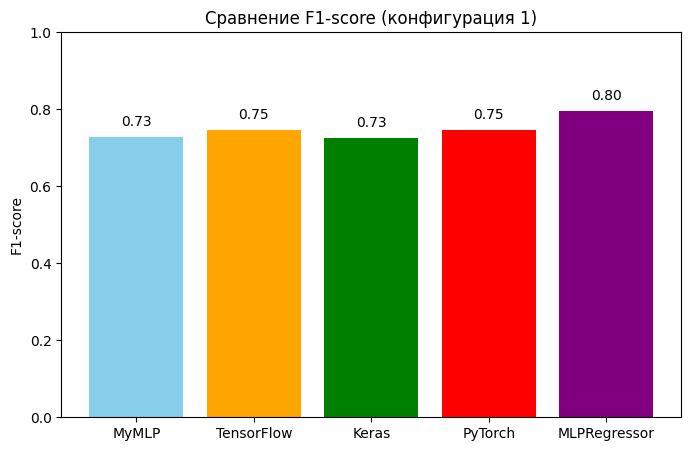

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['1 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 1)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

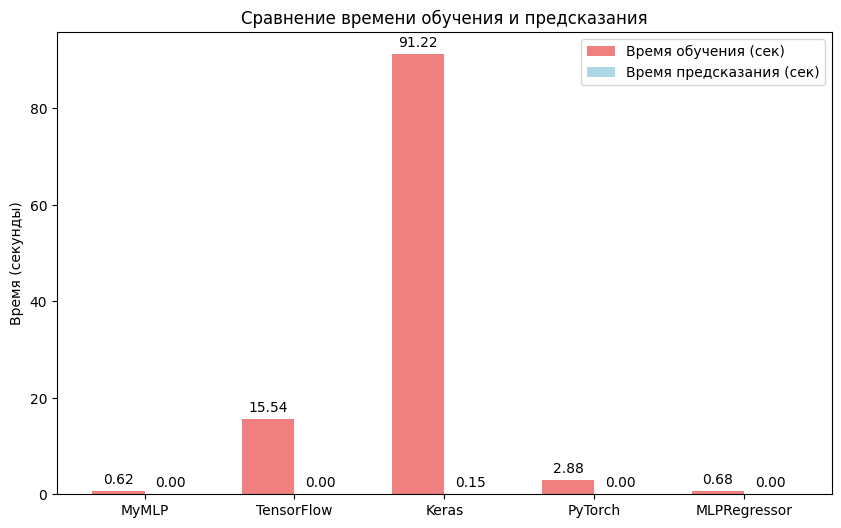

In [ ]:
fit_times = [results_dict[f]['1 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['1 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**2 вариант.** 2 скрытых слоя (16, 32) .

In [ ]:
#MyMLP
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 32), MyMLP.ReLU()),
     (MyMLP.Dense(32, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 1), MyMLP.Linear())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.MSE(),
              optimization='SGD', batch_size = 32,
              alpha = 0.001, max_iter=1000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['2 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8101094079950213
Время обучения:  4.294
Время предсказания:  0.0003


In [ ]:
#MLPRegressor
start_time = time.time()
model = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=1000, random_state = 42, solver='sgd', batch_size=32)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPRegressor']['2 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8443302909447985
Время обучения:  5.065
Время предсказания:  0.00069


In [ ]:
# TensorFlow
start_time = time.time()

X_train_tf = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
hidden1_dim = 32
hidden2_dim = 16
output_dim = 1

def he_init(shape):
    return tf.Variable(tf.random.normal(shape) * np.sqrt(2.0 / shape[0]))

W1 = he_init((input_dim, hidden1_dim))
b1 = tf.Variable(tf.zeros((hidden1_dim,), dtype=tf.float32))

W2 = he_init((hidden1_dim, hidden2_dim))
b2 = tf.Variable(tf.zeros((hidden2_dim,), dtype=tf.float32))

W3 = he_init((hidden2_dim, output_dim))
b3 = tf.Variable(tf.zeros((output_dim,), dtype=tf.float32))


learning_rate = 0.001
epochs = 1000
early_stopping = 0.001
batch_size = 32

def MSE(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def relu(x):
  return tf.nn.relu(x)

def forward_pass(X):
    # Слой 1
    z1 = tf.matmul(X, W1) + b1
    a1 = relu(z1)
    # Слой 2
    z2 = tf.matmul(a1, W2) + b2
    a2 = relu(z2)
    # Слой 3
    z3 = tf.matmul(a2, W3) + b3
    a3 = z3
    return a3

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    loss = MSE(y, y_pred)

  gradients = tape.gradient(loss, [W1, b1, W2, b2, W3, b3])
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip([W1, b1, W2, b2, W3, b3], gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []

  for i in range(0, X_train_tf.shape[0], batch_size):
    x_batch = X_train_tf[i:i+batch_size]
    y_batch = y_train_tf[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break

end_time = time.time()
fit_time = end_time - start_time

X_test_tf = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

def predict(X):
  probs = forward_pass(X).numpy()
  return probs

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['2 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7922744095463854
Время обучения:  44.884
Время предсказания:  0.00729


In [ ]:
#Keras
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(32, activation=keras.activations.relu))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(1, activation=keras.activations.linear))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.MeanSquaredError()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1000, batch_size = 32, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['2 conf'] = [r2, fit_time, pred_time]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
R2 score:  0.8248790905396123
Время обучения:  119.451
Время предсказания:  0.20267


In [ ]:
#PyTorch
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

start_time = time.time()
model.train()
for epoch in range(1000):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = model(X_test_pt).numpy()
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['2 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8358046514351805
Время обучения:  25.551
Время предсказания:  0.0004


**Визуализация**

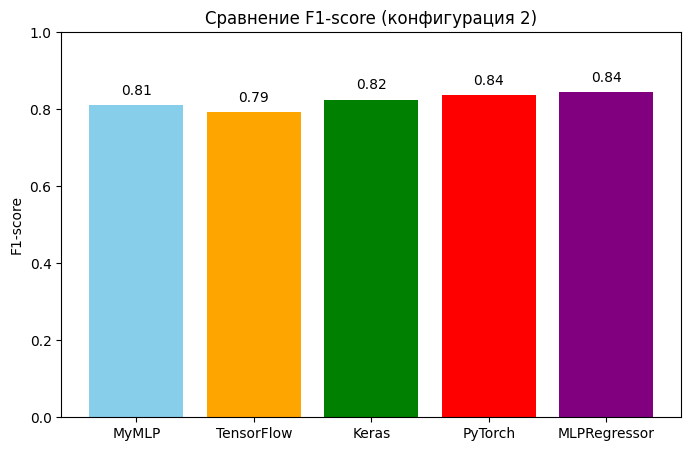

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['2 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 2)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

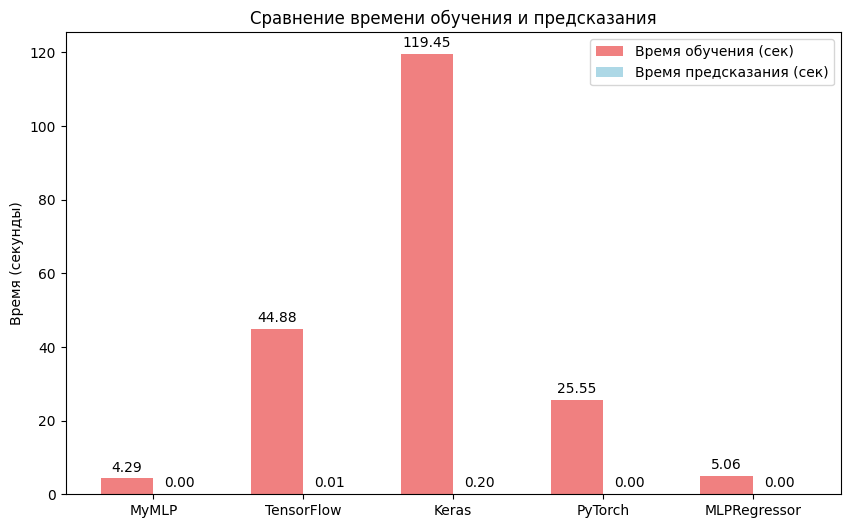

In [ ]:
fit_times = [results_dict[f]['2 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['2 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**3 вариант.** 3 скрытых слоя (16, 16, 16) .

In [ ]:
#MyMLP
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 16), MyMLP.ReLU()),
    (MyMLP.Dense(16, 16), MyMLP.ReLU()),
     (MyMLP.Dense(16, 1), MyMLP.Linear())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.MSE(),
              optimization='SGD', batch_size = 16,
              alpha = 0.001, max_iter=1000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['3 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8039705473622907
Время обучения:  6.414
Время предсказания:  0.00024


In [ ]:
#MLPRegressor
start_time = time.time()
model = MLPRegressor(hidden_layer_sizes=(16, 16, 16), max_iter=1000, random_state = 42, solver='sgd', batch_size=16)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPRegressor']['3 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7963146906325126
Время обучения:  6.699
Время предсказания:  0.00049


In [ ]:
# TensorFlow
start_time = time.time()

X_train_tf = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
output_dims = [16, 16, 16, 1]

def he_init(shape):
    return tf.Variable(tf.random.normal(shape, dtype=tf.float32) * np.sqrt(2.0 / shape[0]))

W = [he_init((input_dim, output_dims[0]))]
b = [tf.Variable(tf.zeros((output_dims[0],), dtype=tf.float32))]
WB = []

for i in range(1, len(output_dims)):
  W.append(he_init((output_dims[i-1], output_dims[i])))
  b.append(tf.Variable(tf.zeros((output_dims[i],), dtype=tf.float32)))

for i in range(0, len(output_dims)):
  WB.append(W[i])
  WB.append(b[i])

learning_rate = 0.001
epochs = 1000
early_stopping = 0.001
batch_size = 16

def MSE(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def relu(x):
  return tf.nn.relu(x)

def forward_pass(X):
  z = tf.matmul(X, W[0]) + b[0]
  a = relu(z)
  for i in range (1, len(output_dims) - 1):
    z = tf.matmul(a, W[i]) + b[i]
    z = tf.clip_by_value(z, -10.0, 10.0)
    a = relu(z)
  z = tf.matmul(a, W[len(output_dims) - 1]) + b[len(output_dims) - 1]
  a = z
  return a

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    loss = MSE(y, y_pred)

  gradients = tape.gradient(loss, WB)
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip(WB, gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []

  for i in range(0, X_train_tf.shape[0], batch_size):
    x_batch = X_train_tf[i:i+batch_size]
    y_batch = y_train_tf[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break

end_time = time.time()
fit_time = end_time - start_time

X_test_tf = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

def predict(X):
  probs = forward_pass(X).numpy()
  return probs

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['3 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7992983025989009
Время обучения:  101.518
Время предсказания:  0.00935


In [ ]:
#Keras
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(16, activation=keras.activations.relu))
model.add(keras.layers.Dense(1, activation=keras.activations.linear))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.MeanSquaredError()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1000, batch_size = 16, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['3 conf'] = [r2, fit_time, pred_time]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
R2 score:  0.8261029809198491
Время обучения:  137.248
Время предсказания:  0.2205


In [ ]:
#PyTorch
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=16)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

start_time = time.time()
model.train()
for epoch in range(1000):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = model(X_test_pt).numpy()
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['3 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8277172328968784
Время обучения:  53.454
Время предсказания:  0.00041


**Визуализация**

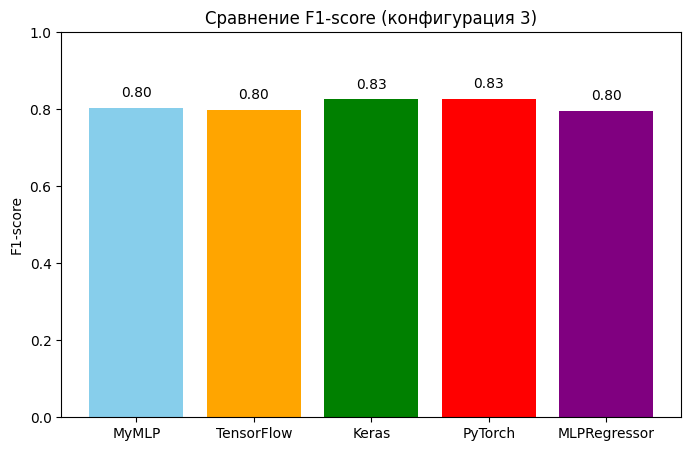

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['3 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 3)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

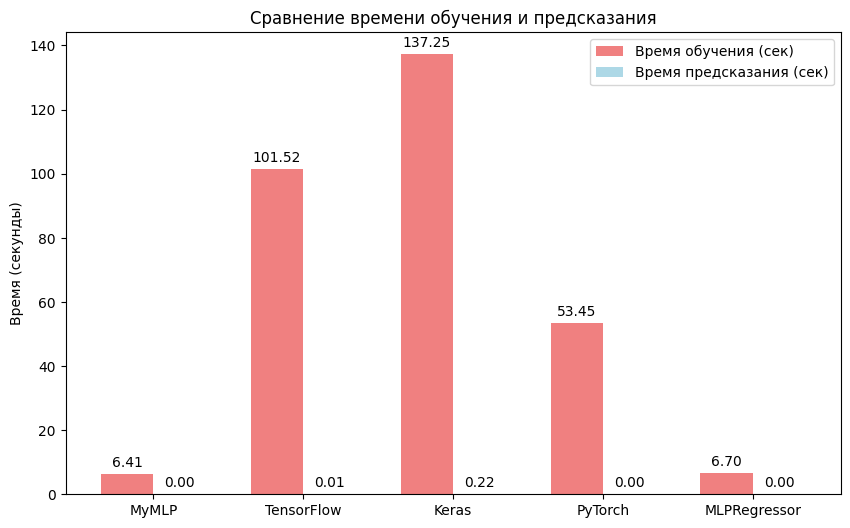

In [ ]:
fit_times = [results_dict[f]['3 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['3 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**4 вариант.** 4 скрытых слоя (128, 256, 64, 32) .

In [ ]:
#MyMLP
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 128), MyMLP.ReLU()),
     (MyMLP.Dense(128, 256), MyMLP.ReLU()),
     (MyMLP.Dense(256, 64), MyMLP.ReLU()),
    (MyMLP.Dense(64, 32), MyMLP.ReLU()),
    (MyMLP.Dense(32, 1), MyMLP.Linear())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.MSE(),
              optimization='SGD', batch_size = 32,
              alpha = 0.001, max_iter=1000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['4 conf'] = [r2, fit_time, pred_time]

R2 score:  0.697468814399544
Время обучения:  38.666
Время предсказания:  0.00113


In [ ]:
#MLPRegressor
start_time = time.time()
model = MLPRegressor(hidden_layer_sizes=(128, 256, 64, 32), max_iter=1000, random_state = 42, solver='sgd', batch_size=32)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPRegressor']['4 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7631080930225403
Время обучения:  22.971
Время предсказания:  0.00152


In [ ]:
# TensorFlow
start_time = time.time()

X_train_tf = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
output_dims = [128, 256, 64, 32, 1]

def he_init(shape):
    return tf.Variable(tf.random.normal(shape, dtype=tf.float32) * np.sqrt(2.0 / shape[0]))

W = [he_init((input_dim, output_dims[0]))]
b = [tf.Variable(tf.zeros((output_dims[0],), dtype=tf.float32))]
WB = []

for i in range(1, len(output_dims)):
  W.append(he_init((output_dims[i-1], output_dims[i])))
  b.append(tf.Variable(tf.zeros((output_dims[i],), dtype=tf.float32)))

for i in range(0, len(output_dims)):
  WB.append(W[i])
  WB.append(b[i])

learning_rate = 0.001
epochs = 1000
early_stopping = 0.001
batch_size = 32

def MSE(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def relu(x):
  return tf.nn.relu(x)

def forward_pass(X):
  z = tf.matmul(X, W[0]) + b[0]
  a = relu(z)
  for i in range (1, len(output_dims) - 1):
    z = tf.matmul(a, W[i]) + b[i]
    z = tf.clip_by_value(z, -10.0, 10.0)
    a = relu(z)
  z = tf.matmul(a, W[len(output_dims) - 1]) + b[len(output_dims) - 1]
  a = z
  return a

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    loss = MSE(y, y_pred)

  gradients = tape.gradient(loss, WB)
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip(WB, gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []

  for i in range(0, X_train_tf.shape[0], batch_size):
    x_batch = X_train_tf[i:i+batch_size]
    y_batch = y_train_tf[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break

end_time = time.time()
fit_time = end_time - start_time

X_test_tf = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

def predict(X):
  probs = forward_pass(X).numpy()
  return probs

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['4 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7052678563627011
Время обучения:  55.315
Время предсказания:  0.01315


In [ ]:
#Keras
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(128, activation=keras.activations.relu))
model.add(keras.layers.Dense(256, activation=keras.activations.relu))
model.add(keras.layers.Dense(64, activation=keras.activations.relu))
model.add(keras.layers.Dense(32, activation=keras.activations.relu))
model.add(keras.layers.Dense(1, activation=keras.activations.linear))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.MeanSquaredError()
)
history = model.fit(X_train_tf, y_train_tf, epochs=1000, batch_size = 32, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['4 conf'] = [r2, fit_time, pred_time]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
R2 score:  0.8219679438041944
Время обучения:  92.233
Время предсказания:  0.35752


In [ ]:
#PyTorch
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

start_time = time.time()
model.train()
for epoch in range(1000):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = model(X_test_pt).numpy()
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['4 conf'] = [r2, fit_time, pred_time]

R2 score:  0.84540397542049
Время обучения:  38.316
Время предсказания:  0.00117


**Визуализация**

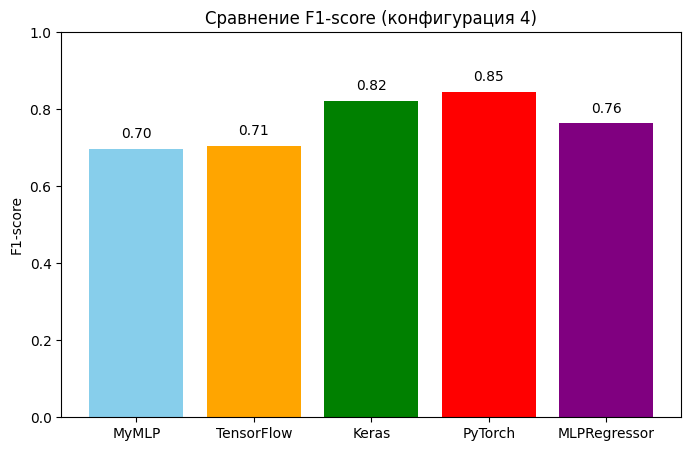

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['4 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 4)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

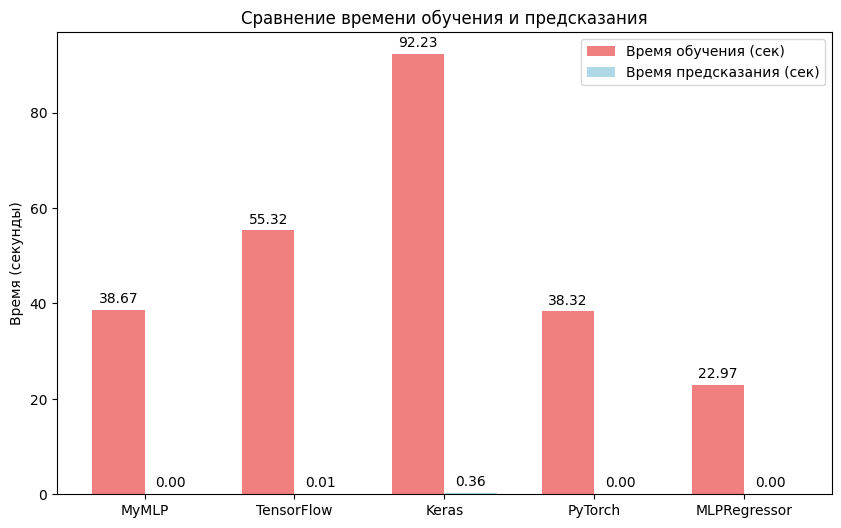

In [ ]:
fit_times = [results_dict[f]['4 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['4 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

###**5 вариант.** 3 скрытых слоя (512, 256, 128) + регуляризация.

In [ ]:
#MyMLP
start_time = time.time()

layers = [
    (MyMLP.Dense(input_shape, 512), MyMLP.ReLU()),
     (MyMLP.Dense(512, 256), MyMLP.ReLU()),
    (MyMLP.Dense(256, 128), MyMLP.ReLU()),
     (MyMLP.Dense(128, 1), MyMLP.Linear())
]

model = MyMLP(Layers=layers,
              Loss=MyMLP.MSE(),
              optimization='SGD', batch_size = 32, lambda_2 = 0.01,
              alpha = 0.001, max_iter=3000)

losses = model.fit(X_train_processed, y_train)

end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MyMLP']['5 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8196103966267096
Время обучения:  278.348
Время предсказания:  0.00222


In [ ]:
#MLPRegressor
start_time = time.time()
model = MLPRegressor(hidden_layer_sizes=(512, 256, 128), max_iter=3000, random_state = 42, solver='sgd', batch_size=32, alpha=0.01)
model.fit(X_train_processed, y_train.ravel())
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['MLPRegressor']['5 conf'] = [r2, fit_time, pred_time]

R2 score:  0.7972554589233718
Время обучения:  54.564
Время предсказания:  0.00233


In [ ]:
# TensorFlow
start_time = time.time()

X_train_tf = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = input_shape
output_dims = [512, 256, 128, 1]

def he_init(shape):
    return tf.Variable(tf.random.normal(shape, dtype=tf.float32) * np.sqrt(2.0 / shape[0]))

W = [he_init((input_dim, output_dims[0]))]
b = [tf.Variable(tf.zeros((output_dims[0],), dtype=tf.float32))]
WB = []

for i in range(1, len(output_dims)):
  W.append(he_init((output_dims[i-1], output_dims[i])))
  b.append(tf.Variable(tf.zeros((output_dims[i],), dtype=tf.float32)))

for i in range(0, len(output_dims)):
  WB.append(W[i])
  WB.append(b[i])

learning_rate = 0.001
epochs = 3000
early_stopping = 0.001
batch_size = 32
l2_lambda = 0.01

def MSE(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def relu(x):
  return tf.nn.relu(x)

def forward_pass(X):
  z = tf.matmul(X, W[0]) + b[0]
  a = relu(z)
  for i in range (1, len(output_dims) - 1):
    z = tf.matmul(a, W[i]) + b[i]
    z = tf.clip_by_value(z, -10.0, 10.0)
    a = relu(z)
  z = tf.matmul(a, W[len(output_dims) - 1]) + b[len(output_dims) - 1]
  a = z
  return a

@tf.function
def train_step(X, y):
  with tf.GradientTape() as tape:
    y_pred = forward_pass(X)
    mse_loss = MSE(y, y_pred)
    l2_loss = l2_lambda * tf.add_n([tf.reduce_sum(tf.square(w)) for w in W])
    loss = mse_loss + l2_loss

  gradients = tape.gradient(loss, WB)
  gradients = [tf.clip_by_norm(g, 1.0) if g is None else g for g in gradients]
  for var, grad in zip(WB, gradients):
    var.assign_sub(learning_rate * grad)

  return loss, tf.norm(gradients[0])

history = []
for epoch in range(epochs):

  losses_epoch = []

  for i in range(0, X_train_tf.shape[0], batch_size):
    x_batch = X_train_tf[i:i+batch_size]
    y_batch = y_train_tf[i:i+batch_size]

    loss, grad_norm = train_step(x_batch, y_batch)
    losses_epoch.append(loss.numpy())

    if loss < early_stopping:
      break

end_time = time.time()
fit_time = end_time - start_time

X_test_tf = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

def predict(X):
  probs = forward_pass(X).numpy()
  return probs

start_time = time.time()
y_pred = predict(X_test_tf)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['TensorFlow']['5 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8166032799261755
Время обучения:  162.61
Время предсказания:  0.01092


In [ ]:
#Keras
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

start_time = time.time()
model = keras.Sequential()
model.add(keras.layers.Input(shape=X_train_processed.shape[1:]))
model.add(keras.layers.Dense(512, kernel_regularizer=keras.regularizers.l2(0.01), activation=keras.activations.relu))
model.add(keras.layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.01), activation=keras.activations.relu))
model.add(keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(0.01), activation=keras.activations.relu))
model.add(keras.layers.Dense(1, kernel_regularizer=keras.regularizers.l2(0.01), activation=keras.activations.linear))

early_stop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00001, patience=0, restore_best_weights=True)

model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = keras.losses.MeanSquaredError()
)
history = model.fit(X_train_tf, y_train_tf, epochs=3000, batch_size = 32, verbose=0, callbacks = [early_stop])
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
y_pred = model.predict(X_test_processed)
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['Keras']['5 conf'] = [r2, fit_time, pred_time]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
R2 score:  0.849386190396065
Время обучения:  266.4
Время предсказания:  0.23977


In [ ]:
#PyTorch
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_dataloader = DataLoader(train_dataset, batch_size=32)

model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, weight_decay = 0.01)
loss_fn = nn.MSELoss()

start_time = time.time()
model.train()
for epoch in range(3000):
  for batch, (X, y) in enumerate(train_dataloader):
    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
end_time = time.time()
fit_time = end_time - start_time

start_time = time.time()
model.eval()
with torch.no_grad():
    y_pred = model(X_test_pt).numpy()
end_time = time.time()
pred_time = end_time - start_time

r2 = r2_score(y_test, y_pred)
print("R2 score: ", r2)
print("Время обучения: ", round(fit_time, 3))
print("Время предсказания: ", round(pred_time, 5))

results_dict['PyTorch']['5 conf'] = [r2, fit_time, pred_time]

R2 score:  0.8328224626475171
Время обучения:  137.949
Время предсказания:  0.00176


**Визуализация**

In [ ]:
frameworks = list(results_dict.keys())
f1_scores = [results_dict[f]['5 conf'][0] for f in frameworks]

plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, f1_scores, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylabel('F1-score')
plt.title('Сравнение F1-score (конфигурация 5)')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom')
plt.show()

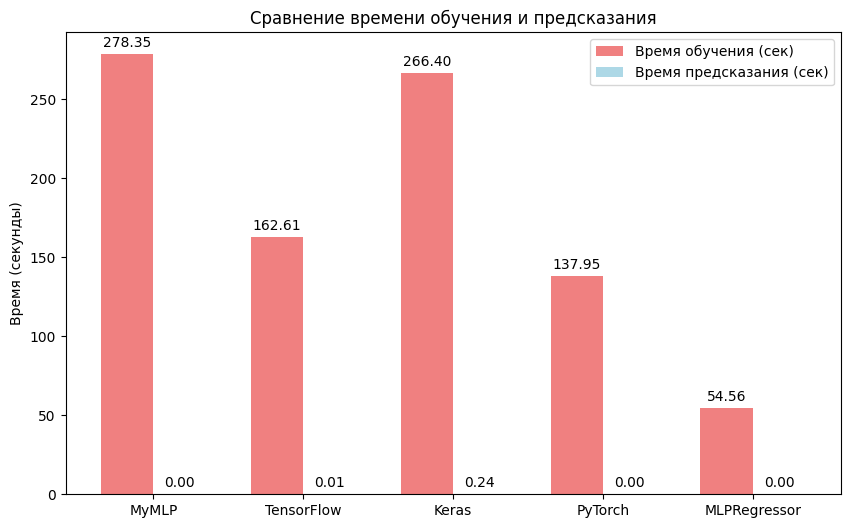

In [ ]:
fit_times = [results_dict[f]['5 conf'][1] for f in frameworks]
pred_times = [results_dict[f]['5 conf'][2] for f in frameworks]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, fit_times, width, label='Время обучения (сек)', color='lightcoral')
bars2 = ax.bar(x + width/2, pred_times, width, label='Время предсказания (сек)', color='lightblue')

ax.set_ylabel('Время (секунды)')
ax.set_title('Сравнение времени обучения и предсказания')
ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
plt.show()

In [ ]:
regression_res = results_dict

In [ ]:
pd.DataFrame(regression_res)

,MyMLP,TensorFlow,Keras,PyTorch,MLPRegressor
1 conf,"[0.7287254204354323, 0.6197776794433594, 0.000...","[0.7473642129536842, 15.535736083984375, 0.004...","[0.7252512452682518, 91.21886706352234, 0.1505...","[0.7474166966295659, 2.8840315341949463, 0.000...","[0.7960174104659015, 0.6838278770446777, 0.000..."
2 conf,"[0.8101094079950213, 4.293561220169067, 0.0003...","[0.7922744095463854, 44.88424277305603, 0.0072...","[0.8248790905396123, 119.45117402076721, 0.202...","[0.8358046514351805, 25.551456212997437, 0.000...","[0.8443302909447985, 5.064656734466553, 0.0006..."
3 conf,"[0.8039705473622907, 6.4140026569366455, 0.000...","[0.7992983025989009, 101.51778101921082, 0.009...","[0.8261029809198491, 137.24808621406555, 0.220...","[0.8277172328968784, 53.45438814163208, 0.0004...","[0.7963146906325126, 6.69910740852356, 0.00049..."
4 conf,"[0.697468814399544, 38.66559028625488, 0.00113...","[0.7052678563627011, 55.31532406806946, 0.0131...","[0.8219679438041944, 92.23324203491211, 0.3575...","[0.84540397542049, 38.316303730010986, 0.00116...","[0.7631080930225403, 22.970547437667847, 0.001..."
5 conf,"[0.8196103966267096, 278.3476414680481, 0.0022...","[0.8166032799261755, 162.60968828201294, 0.010...","[0.849386190396065, 266.3998980522156, 0.23976...","[0.8328224626475171, 137.94900369644165, 0.001...","[0.7972554589233718, 54.56378483772278, 0.0023..."


In [ ]:
pd.DataFrame(regression_res).to_csv('regression_res.csv', index=False)

# Итоговое сравнение

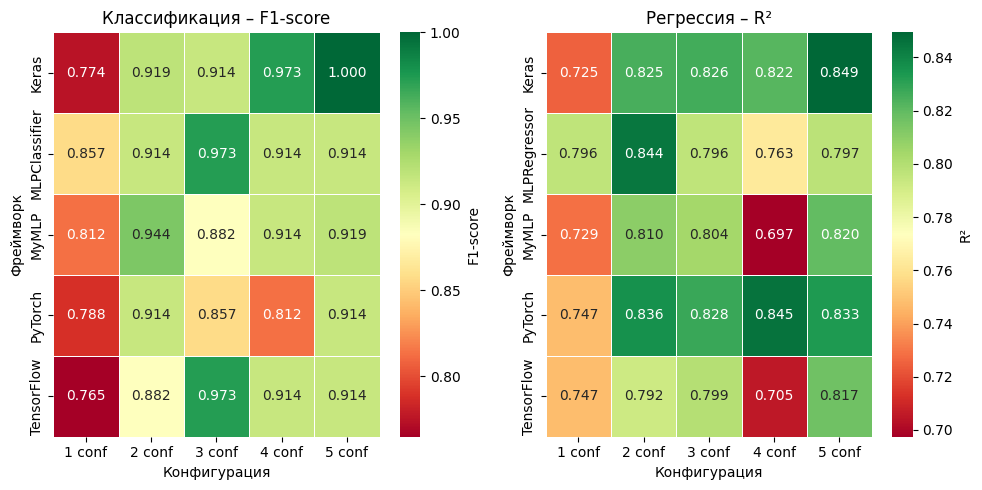

In [ ]:
data_cls = []
for framework in ['MyMLP', 'TensorFlow', 'Keras', 'PyTorch', 'MLPClassifier']:
    for conf_name, (metric, fit_time, pred_time) in classification_res[framework].items():
        data_cls.append({'Фреймворк': framework, 'Конфигурация': conf_name, 'Метрика': metric})
df_cls = pd.DataFrame(data_cls)
pivot_cls = df_cls.pivot(index='Фреймворк', columns='Конфигурация', values='Метрика')

data_reg = []
for framework in ['MyMLP', 'TensorFlow', 'Keras', 'PyTorch', 'MLPRegressor']:
    for conf_name, (metric, fit_time, pred_time) in regression_res[framework].items():
        data_reg.append({'Фреймворк': framework, 'Конфигурация': conf_name, 'Метрика': metric})
df_reg = pd.DataFrame(data_reg)
pivot_reg = df_reg.pivot(index='Фреймворк', columns='Конфигурация', values='Метрика')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.heatmap(pivot_cls, annot=True, cmap='RdYlGn', fmt='.3f', linewidths=0.5, ax=ax1, cbar_kws={'label': 'F1-score'})
ax1.set_title('Классификация – F1-score')

sns.heatmap(pivot_reg, annot=True, cmap='RdYlGn', fmt='.3f', linewidths=0.5, ax=ax2, cbar_kws={'label': 'R²'})
ax2.set_title('Регрессия – R²')

plt.tight_layout()
plt.show()

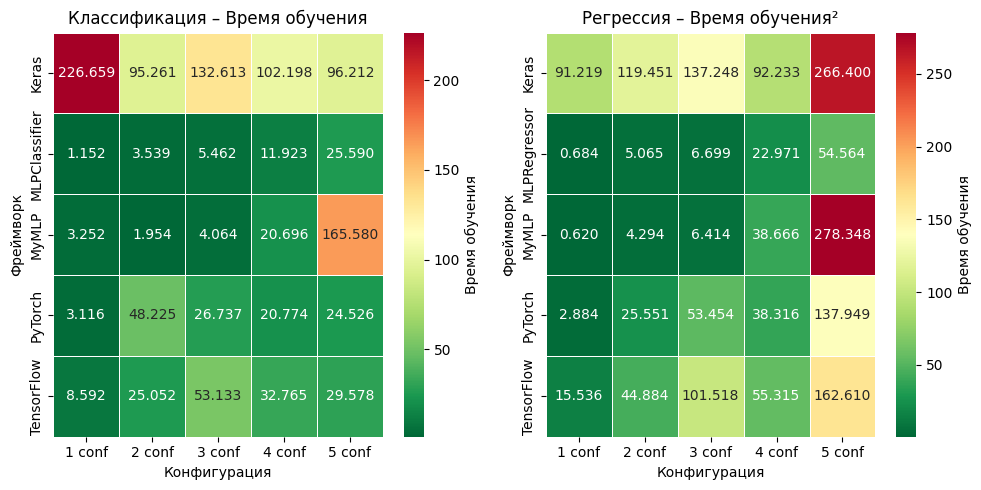

In [ ]:
data_cls = []
for framework in ['MyMLP', 'TensorFlow', 'Keras', 'PyTorch', 'MLPClassifier']:
    for conf_name, (metric, fit_time, pred_time) in classification_res[framework].items():
        data_cls.append({'Фреймворк': framework, 'Конфигурация': conf_name, 'Время обучения': fit_time})
df_cls = pd.DataFrame(data_cls)
pivot_cls = df_cls.pivot(index='Фреймворк', columns='Конфигурация', values='Время обучения')

data_reg = []
for framework in ['MyMLP', 'TensorFlow', 'Keras', 'PyTorch', 'MLPRegressor']:
    for conf_name, (metric, fit_time, pred_time) in regression_res[framework].items():
        data_reg.append({'Фреймворк': framework, 'Конфигурация': conf_name, 'Время обучения': fit_time})
df_reg = pd.DataFrame(data_reg)
pivot_reg = df_reg.pivot(index='Фреймворк', columns='Конфигурация', values='Время обучения')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.heatmap(pivot_cls, annot=True, cmap='RdYlGn_r', fmt='.3f', linewidths=0.5, ax=ax1, cbar_kws={'label': 'Время обучения'})
ax1.set_title('Классификация – Время обучения')

sns.heatmap(pivot_reg, annot=True, cmap='RdYlGn_r', fmt='.3f', linewidths=0.5, ax=ax2, cbar_kws={'label': 'Время обучения'})
ax2.set_title('Регрессия – Время обучения²')

plt.tight_layout()
plt.show()